# Goal:



*   Predict the probability a person will repay their loan.
*   Measured in Area Under the ROC Curve (AUC).
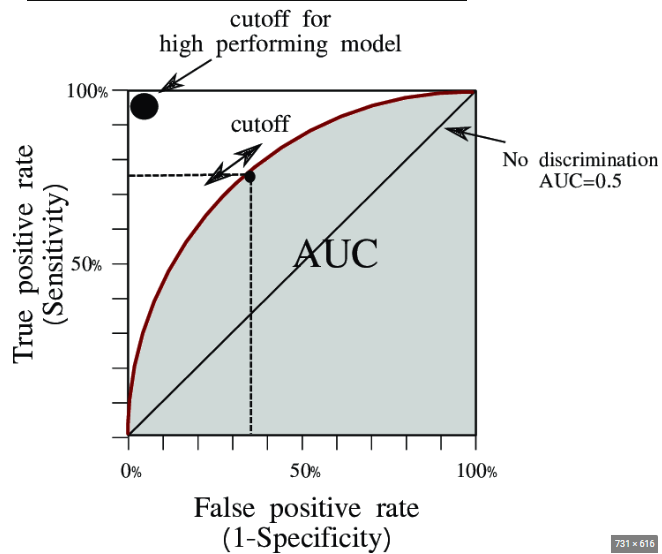


# Pre-Reqs:

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold

# Data:

In [ ]:
#Creating datframe from test and train csv's
TrainDataset = pd.read_csv('/content/train.csv')
TestDataset = pd.read_csv('/content/test.csv')

#Creating some additional dataframes to not be encoded
TrainNoEncDataset = pd.read_csv('/content/train.csv')
TestNoEncDataset = pd.read_csv('/content/test.csv')

In [ ]:
TrainNoEncDataset.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [ ]:
TrainDataset.info()
print("\n")
TrainDataset.describe()
print("\n")
TrainDataset.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB






,0
id,0
annual_income,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0
interest_rate,0
gender,0
marital_status,0
education_level,0
employment_status,0


# Data-Cleanup/Pre-Processing:

In [ ]:
#Pre-proccessing rebuild into function

def FeatureEngineering(DF):

  DF = DF.copy()

  ###########annual_income column
  #Log-Transform
  DF['log_annual_income'] = np.log1p(DF['annual_income'])
  #Binning
  DF['income_bin'] = pd.qcut(DF['annual_income'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
  #Affordability
  DF['loan_to_income_ratio'] = DF['loan_amount'] / (DF['annual_income'] + 1e-5)
  #Replicate to TestDataset
  bins = pd.qcut(DF['annual_income'], q=5, retbins=True)[1]
  DF['income_bin'] = pd.cut(DF['annual_income'], bins=bins, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'], include_lowest=True)
  DF['log_annual_income'] = np.log1p(DF['annual_income'])
  DF['loan_to_income_ratio'] = DF['loan_amount'] / (DF['annual_income'] + 1e-5)

 ###########education_level
  edu_map = {
    'High School': 1,
    'Bachelor\'s': 2,
    'Master\'s': 3,
    'PhD': 4
  }

  DF['education_ord'] = DF['education_level'].map(edu_map)
  DF['education_ord'] = DF['education_ord'].fillna(0)
  DF['education_ord'] = DF['education_ord'].astype(int)
  DF['education_ord'] = DF['education_ord'].astype(str)

  ###########credit_score
  credit_bins = [300, 580, 670, 740, 800, 900]   # FICO-like bands
  DF['credit_bin'] = pd.cut(DF['credit_score'], bins=credit_bins, labels=False, include_lowest=True)

  ###########interest_rate
  DF['rate_bin'] = pd.qcut(DF['interest_rate'], q=4, labels=False)
  DF['rate_sq'] = DF['interest_rate'] ** 2

  DF['rate_bin'] = DF['rate_bin'].map(edu_map)
  DF['rate_bin'] = DF['rate_bin'].fillna(0)
  DF['rate_bin'] = DF['rate_bin'].astype(int)
  DF['rate_bin'] = DF['rate_bin'].astype(str)
  DF['rate_sq'] = DF['rate_sq'].map(edu_map)
  DF['rate_sq'] = DF['rate_sq'].fillna(0)
  DF['rate_sq'] = DF['rate_sq'].astype(int)
  DF['rate_sq'] = DF['rate_sq'].astype(str)

  return DF


#Run pre-processing techniques onto dataframes
TrainDataset = FeatureEngineering(TrainDataset)
TestDataset  = FeatureEngineering(TestDataset)

In [ ]:
Features = ["gender", "marital_status", "education_level", "employment_status", "loan_purpose", "grade_subgrade"]

label_encoders = {}
for col in Features:
    le = LabelEncoder()
    TrainDataset[col] = le.fit_transform(TrainDataset[col])
    TestDataset[col] = le.transform(TestDataset[col])  # use same mapping for test
    label_encoders[col] = le  # store encoders if needed later

In [ ]:
#Re-check if datasets are fully numeric
Train_Numerical = TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print(f"Test Dataset Numerical? {Train_Numerical}")
Test_Numerical = TestDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()
print(f"Test Dataset Numerical? {Test_Numerical}")

/tmp/ipython-input-699104718.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  Train_Numerical = TrainDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()


Test Dataset Numerical? False


/tmp/ipython-input-699104718.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  Test_Numerical = TestDataset.applymap(lambda x: isinstance(x, (int, float))).all().all()


Test Dataset Numerical? False


# Data Analysis:

**Plan**:
* CatBoost
* LightGBM
* Blend/Stack them.



 Feature Engineering Ideas for Loan Repayment Dataset

 Columns and Ideas

- **debt_to_income_ratio** (Numeric)
  - Already informative
  - Optionally bin into quantiles (“low”, “medium”, “high”)
  - Interact with credit_score or loan_amount

- **credit_score** (Numeric)
  - Bin into credit tiers (e.g., 300–579, 580–669, 670–739, etc.)
  - Interaction with interest_rate or grade_subgrade

- **loan_amount** (Numeric)
  - Log-transform to compress large tails
  - Ratio: loan_amount / annual_income (loan burden)
  - Interaction with interest_rate to estimate repayment burden

- **interest_rate** (Numeric)
  - Polynomial features (rate^2) or bin into ranges (<10%, 10–15%, >15%)
  - High rates often imply higher default risk

- **gender** (Categorical)
  - One-hot encode or label encode
  - Optionally drop if not predictive

- **marital_status** (Categorical)
  - One-hot encode
  - Interaction with education_level or employment_status

- **education_level** (Categorical)
  - Ordinal encode (High School < Bachelor’s < Master’s < PhD)
  - Interaction with annual_income

- **employment_status** (Categorical)
  - Encode as category
  - Group rare classes under “Other”
  - Interaction with annual_income and credit_score

- **loan_purpose** (Categorical)
  - Target or mean encode (default rate per category)
  - Group rare purposes together
  - Interaction with loan_amount

- **grade_subgrade** (Ordinal categorical)
  - Split into grade (A–G) and subgrade (1–5)
  - Map grade to numeric (A=7 … G=1)
  - Optionally combine as a single numeric index

Cross-feature / Interaction Ideas

- Loan-to-Income Ratio: loan_amount / annual_income
- Income-to-Interest Ratio: annual_income / interest_rate
- Credit × Debt Interaction: credit_score * (1 - debt_to_income_ratio)
- Effective Rate per Credit Tier: deviation of interest_rate from mean by credit_score band
- Loan Burden per Employment Type: loan_amount / annual_income grouped by employment_status
- Debt Grade Index: map grade_subgrade to a single numeric value

 Statistical Transformations

- **Binning**
  ```python
  train['income_bin'] = pd.qcut(train['annual_income'], 5, labels=False)
  train['credit_bin'] = pd.cut(train['credit_score'], bins=[300,580,670,740,800,850], labels=False)


# Model 1 - CatBoost:

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

# -----------------------------------------
# DATA
# -----------------------------------------
X = TrainDataset.drop(columns=["loan_paid_back", "id"]).copy()
y = TrainDataset["loan_paid_back"].copy()
X_test = TestDataset.drop(columns=["id"]).copy()

categorical_features = [
    'gender', 'marital_status', 'education_level',
    'employment_status', 'loan_purpose', 'grade_subgrade',
    'income_bin','education_ord','credit_bin','rate_bin','rate_sq'
]

# Convert categorical columns to string (CatBoost requirement)
for col in categorical_features:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# -----------------------------------------
# K-FOLD CONFIG
# -----------------------------------------
NFOLDS = 7
skf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold = 1

# -----------------------------------------
# TRAIN K-FOLD LOOP
# -----------------------------------------
for train_idx, valid_idx in skf.split(X, y):

    print(f"\n🔥 Training Fold {fold}/{NFOLDS}")

    X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

    # Create new model each fold
    model = CatBoostClassifier(
        iterations=1222,
        learning_rate=0.05,
        depth=8,
        eval_metric='AUC',
        random_seed=42 + fold,
        verbose=124,
        early_stopping_rounds=75
    )

    # Fit
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        cat_features=categorical_features
    )

    # OOF predictions
    oof_preds[valid_idx] = model.predict_proba(X_val)[:, 1]

    # Add fold’s test predictions
    test_preds += model.predict_proba(X_test)[:, 1] / NFOLDS

    fold += 1


cv_auc = roc_auc_score(y, oof_preds)
print("\n==============================")
print(f"🔥 FINAL {NFOLDS}-Fold CV AUC = {cv_auc:.5f}")
print("==============================")


submission = pd.DataFrame({
    "id": TestDataset["id"],
    "loan_paid_back": test_preds
})

submission.to_csv("KaggleModel1BaselineCatBoost.csv", index=False)



🔥 Training Fold 1/7
0:	test: 0.8986266	best: 0.8986266 (0)	total: 2.17s	remaining: 44m 14s
124:	test: 0.9172050	best: 0.9172050 (124)	total: 3m 53s	remaining: 34m 9s
248:	test: 0.9187913	best: 0.9187913 (248)	total: 7m 52s	remaining: 30m 46s
372:	test: 0.9205003	best: 0.9205003 (372)	total: 12m 12s	remaining: 27m 48s
496:	test: 0.9213815	best: 0.9213815 (496)	total: 16m 38s	remaining: 24m 16s
620:	test: 0.9221185	best: 0.9221230 (618)	total: 20m 58s	remaining: 20m 17s
744:	test: 0.9225796	best: 0.9225820 (743)	total: 25m 14s	remaining: 16m 9s
868:	test: 0.9229757	best: 0.9229757 (868)	total: 29m 34s	remaining: 12m
992:	test: 0.9232178	best: 0.9232276 (987)	total: 33m 50s	remaining: 7m 48s
1116:	test: 0.9234728	best: 0.9234739 (1115)	total: 38m 8s	remaining: 3m 35s
1221:	test: 0.9236334	best: 0.9236362 (1218)	total: 41m 49s	remaining: 0us

bestTest = 0.9236362209
bestIteration = 1218

Shrink model to first 1219 iterations.

🔥 Training Fold 2/7
0:	test: 0.8913237	best: 0.8913237 (0)	tot

# Model 2 - LightGBM:

In [ ]:
target = "loan_paid_back"
id_col = "id"

y_train = TrainDataset[target]
X_train = TrainDataset.drop([target], axis=1)
X_test  = TestDataset.copy()

categorical_features = [
    'gender', 'marital_status', 'education_level',
    'employment_status', 'loan_purpose', 'grade_subgrade',
    'income_bin', 'education_ord', 'credit_bin', 'rate_bin'
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features + [id_col]
]

#Convert types
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')
    X_test[col] = X_test[col].cat.set_categories(X_train[col].cat.categories)

for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0)
    X_test[col]  = pd.to_numeric(X_test[col], errors='coerce').fillna(0)

X_train_split, X_valid, y_train_split, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

model_lgb = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    learning_rate=0.02,
    num_leaves=272,
    max_depth=-1,
    n_estimators=5055,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=3,
    reg_lambda=3,
    random_state=42
)

model_lgb.fit(
    X_train_split, y_train_split,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    categorical_feature=categorical_features
)

#Validation predictions
y_valid_pred_lgb = model_lgb.predict_proba(X_valid)[:, 1]
auc_lgb = roc_auc_score(y_valid, y_valid_pred_lgb)
print("LightGBM validation AUC:", auc_lgb)

#Test predictions
y_test_pred_lgb = model_lgb.predict_proba(X_test)[:, 1]

submission_lgb = pd.DataFrame({
    id_col: TestDataset[id_col],
    target: y_test_pred_lgb
})
submission_lgb.to_csv("KaggleModel2LightGBM.csv", index=False)


[LightGBM] [Info] Number of positive: 379692, number of negative: 95503
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2117
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.799024 -> initscore=1.380203
[LightGBM] [Info] Start training from score 1.380203
LightGBM validation AUC: 0.9184387835966398


# Model 3 - Ensemble of Catboost and Light GBM:

In [ ]:
#Search for best weight on validation set
best_auc = 0
best_w = 0

for w in np.linspace(0, 1, 101):
    blended = w * y_valid_pred_cb + (1 - w) * y_valid_pred_lgb
    auc = roc_auc_score(y_valid, blended)
    if auc > best_auc:
        best_auc = auc
        best_w = w

print("Optimal CatBoost weight:", best_w)
print("Best validation AUC:", best_auc)


Optimal CatBoost weight: 0.0
Best validation AUC: 0.9184387835966398


In [ ]:
final_pred = best_w * y_test_pred_cb + (1 - best_w) * y_test_pred_lgb

submission_ensemble = pd.DataFrame({
    "id": TestDataset['id'],
    "loan_paid_back": final_pred
})
submission_ensemble.to_csv("KaggleEnsembleOptimized.csv", index=False)


In [ ]:
#Take CSVs of previously ran models and merge
cb = pd.read_csv("KaggleModel1BaselineCatBoost.csv")
lgb = pd.read_csv("KaggleModel2LightGBM.csv")

merged = cb.merge(lgb, on="id", suffixes=("_cb", "_lgb"))

merged["loan_paid_back"] = \
    0.6 * merged["loan_paid_back_cb"] + \
    0.4 * merged["loan_paid_back_lgb"]

submission = merged[["id", "loan_paid_back"]]
submission.to_csv("KaggleEnsembleOfCatBoostLightGBM.csv", index=False)
